##### Objetivos da Analise Exploratoria de Dados
> Este dataset será utilizado para a construção de um modelo estatístico inferencial e preditivo, com o objetivo de estimar a probabilidade de uma pessoa se deslocar para o próximo cômodo da casa.
> 
> Além disso, os dados servirão como base para o treinamento de modelos de aprendizado de máquina, que funcionarão como referências para avaliar o desempenho do modelo estatístico desenvolvido.
> 
> A análise exploratória será conduzida para identificar padrões comportamentais do indivíduo no ambiente doméstico, compreendendo rotinas e possíveis regularidades nos deslocamentos entre os cômodos.


### Visualização da Estrutura do DataSet

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from juntando_df import JuntarArquivoCsv
import json 

In [2]:
# df = JuntarArquivoCsv("../data/dados_brutos_sensores/")
# dfA.salvar_df_csv()
df = pd.read_csv("../data/compilado_dados.csv")

In [3]:
df.shape

(1548731, 5)

In [4]:
df.columns

Index(['timestamp', 'entity_id', 'old_state', 'new_state', 'attributes'], dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1548731 entries, 0 to 1548730
Data columns (total 5 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   timestamp   1548730 non-null  object
 1   entity_id   1548731 non-null  object
 2   old_state   1548729 non-null  object
 3   new_state   1548729 non-null  object
 4   attributes  1548731 non-null  object
dtypes: object(5)
memory usage: 59.1+ MB


In [6]:
df.head()

,timestamp,entity_id,old_state,new_state,attributes
0,2025-07-13T14:00:10.408111,automation.aut_status_bruno,on,on,"{""id"": ""1751855857509"", ""last_triggered"": ""202..."
1,2025-07-13T14:00:10.421765,automation.aut_status_bruno,on,on,"{""id"": ""1751855857509"", ""last_triggered"": ""202..."
2,2025-07-13T14:00:15.773224,sensor.arris_tg1692a_router_download_speed,0.0569704745759571,0.0736161792452594,"{""state_class"": ""measurement"", ""unit_of_measur..."
3,2025-07-13T14:00:15.774808,sensor.arris_tg1692a_router_upload_speed,0.167631198829402,0.168477584259541,"{""state_class"": ""measurement"", ""unit_of_measur..."
4,2025-07-13T14:00:40.716334,media_player.dlna_b13_box,unavailable,unknown,"{""friendly_name"": ""DLNA-B13 Box"", ""supported_f..."


In [7]:
type(df.entity_id.unique())

numpy.ndarray

In [8]:
df.new_state.unique()

array(['on', '0.0736161792452594', '0.168477584259541', ...,
       '0.00302057647734068', '0.0625858898399934', '0.0476680549048276'],
      shape=(864792,), dtype=object)

In [9]:
num_sensores = df["entity_id"].value_counts().reset_index()
num_sensores.columns = ['sensor', 'frequencia']
num_sensores

,sensor,frequencia
0,automation.auto_banheiro,399521
1,automation.aut_status_bruno,122714
2,sensor.upnp_igd_upload_speed,85532
3,sensor.upnp_igd_download_speed,85532
4,sensor.upnp_igd_data_sent,85528
...,...,...
280,scene.liga_desliga_luz_amb_foco,1
281,sensor.home_air_quality_day_4,1
282,sensor.new_darth_vader_location_permission,1
283,sensor.new_darth_vader_sim_2,1


In [10]:
sensores = df["entity_id"].value_counts().head(20)
sensores

entity_id
automation.auto_banheiro                      399521
automation.aut_status_bruno                   122714
sensor.upnp_igd_upload_speed                   85532
sensor.upnp_igd_download_speed                 85532
sensor.upnp_igd_data_sent                      85528
sensor.upnp_igd_data_received                  85528
sensor.upnp_igd_packet_upload_speed            85527
sensor.upnp_igd_uptime                         85527
sensor.upnp_igd_packet_download_speed          85527
sensor.upnp_igd_packets_received               85527
sensor.upnp_igd_packets_sent                   85527
sensor.arris_tg1692a_router_download_speed     47576
sensor.arris_tg1692a_router_upload_speed       47576
automation.aut_lampada_quarto                  20580
camera.192_168_0_33                            14014
camera.admin_mainstream                        13656
camera.admin_substream                         13656
sun.sun                                        12983
media_player.dlna_b13_box           

### Nesse grafico seria adequado colocar o periado da amostra

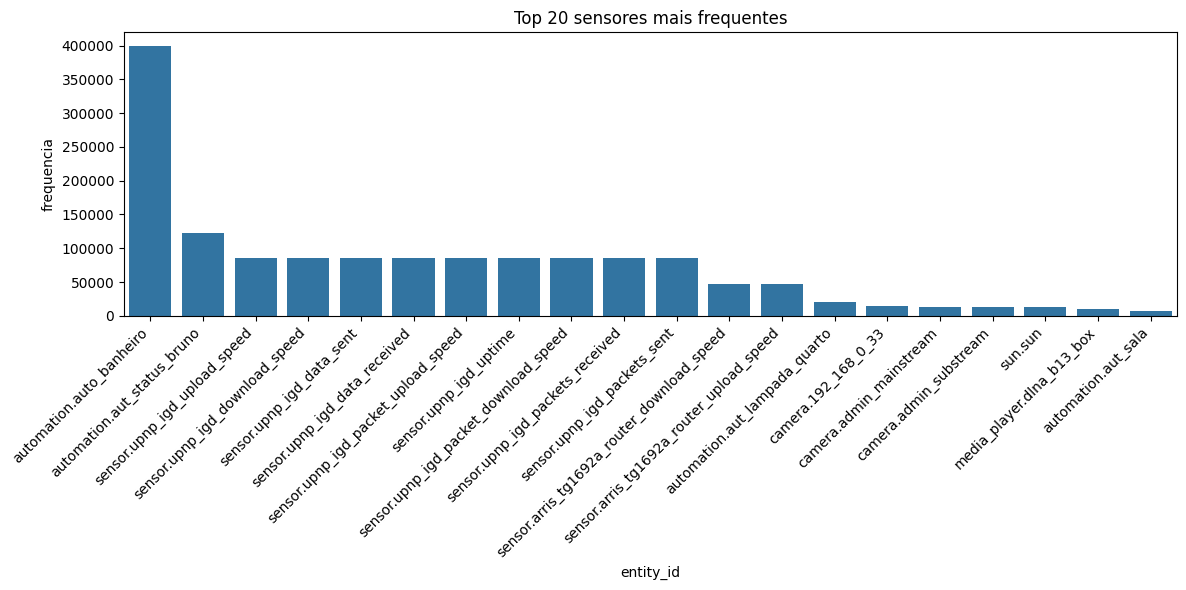

In [11]:
plt.figure(figsize=(12,6))
sns.barplot(x=sensores.index, y=sensores.values)
plt.xticks(rotation=45, ha='right')
plt.ylabel("frequencia")
plt.title("Top 20 sensores mais frequentes")
plt.tight_layout()
plt.show()

In [12]:
json.loads(df["attributes"][1])

{'id': '1751855857509',
 'last_triggered': '2025-07-13T17:00:10.390841+00:00',
 'mode': 'single',
 'current': 0,
 'friendly_name': 'aut-status-bruno'}

### Filtragem dos Dados Prioritarios
> Dados a serem filtrados: 
- [x] Sensores de presença: 
- [] Local onde o sensor esta: friendly_name. 
- [] Estado da Ativação: old_state, new_state. 
- [] Data: timestamp. -> tirar dados compostos de periodo do dia. 
- [] Feriados -> Fazer uma classe dos dias que são feriados.  

#### Entendendo os Sensores de Presença

In [13]:
from limpeza_dados import LimpezaDados
sensores_presenca = LimpezaDados ("entity_id", df)
df_filtro_sem_duplicata = sensores_presenca.filtrar("prese")
df_filtro_sem_duplicata

,entity_id
0,binary_sensor.presenca_sala_motion
1,binary_sensor.presenca_cozinha_motion
2,binary_sensor.presenca_banheiro_motion
3,binary_sensor.human_presence_sensor_occupancy
4,number.human_presence_sensor_sensitivity
5,number.human_presence_sensor_near_detection
6,number.human_presence_sensor_far_detection
7,binary_sensor.sc3_presenca_occupancy
8,binary_sensor.presenca_quarto_motion
9,number.sc3_presenca_sensitivity


In [14]:
df_filtro = sensores_presenca.data_frame_dados_filtrados("prese")
df_presenca = sensores_presenca.tratando_json_sensor_presenca("attributes", df_filtro, True)
df_presenca

,entity_id,old_state,new_state,date,hora,device_class,friendly_name
0,binary_sensor.presenca_sala_motion,off,on,13/07/2025,14:56,motion,Presença sala Motion
1,binary_sensor.presenca_cozinha_motion,off,on,13/07/2025,14:56,motion,Presença cozinha Motion
2,binary_sensor.presenca_banheiro_motion,off,on,13/07/2025,14:57,motion,Presença banheiro Motion
3,binary_sensor.presenca_sala_motion,on,off,13/07/2025,14:57,motion,Presença sala Motion
4,binary_sensor.presenca_cozinha_motion,on,off,13/07/2025,14:57,motion,Presença cozinha Motion
...,...,...,...,...,...,...,...
6944,binary_sensor.human_presence_sensor_occupancy,on,off,14/07/2025,01:46,occupancy,Presença Quarto Occupancy
6945,binary_sensor.presenca_banheiro_motion,off,on,14/07/2025,11:23,motion,Presença banheiro Motion
6946,binary_sensor.presenca_banheiro_motion,on,off,14/07/2025,11:25,motion,Presença banheiro Motion
6947,binary_sensor.human_presence_sensor_occupancy,on,off,14/07/2025,11:51,occupancy,Presença Quarto Occupancy


In [15]:
feriados = pd.read_csv("../data/feriados.csv")
feriados

,2025-01-01
0,2025-03-03
1,2025-03-04
2,2025-03-05
3,2025-04-18
4,2025-04-21
5,2025-05-01
6,2025-06-19
7,2025-06-24
8,2025-07-02
9,2025-09-07
